In [1]:
import pandas as pd
df = pd.read_csv("salaries_india.csv")

# Let's remove the columns "Row ID" and "Job Title":
df = df.drop(["Row ID", "Job Title"], axis=1)
df.head()

,Company Name,Rating,Salary,Salaries Reported,Location,Employment Status,Job Roles
0,Unacademy,Good,2046000.0,3,Bangalore,Full Time,Mobile
1,Appoids Tech Solutions,Good,1227600.0,3,Bangalore,Full Time,Mobile
2,Endeavour Software Technologies,Good,1227600.0,3,Bangalore,Full Time,Mobile
3,Wibmo,Good,1841400.0,2,Bangalore,Full Time,Mobile
4,Bookmyshow,Good,1227600.0,2,Bangalore,Full Time,Mobile


6585    9284422.5
6561    8644117.5
8526    8421043.5
8229    8109153.0
8430    8109153.0
6575    8010090.0
6581    8010090.0
6583    8010090.0
6584    8010090.0
6542    8003812.5
Name: Salary, dtype: float64

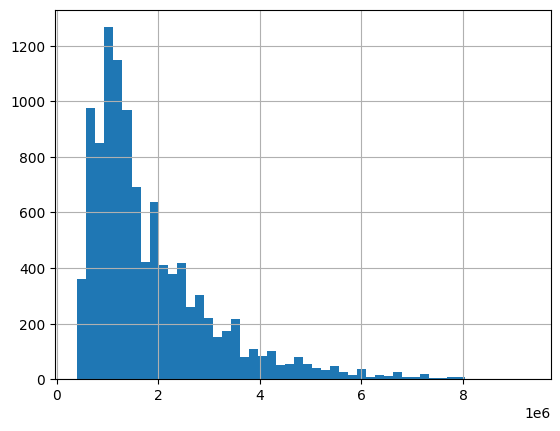

In [3]:
# Let's see what are the highest salaries in this dataset,
# But first let's print the dataset:
df["Salary"].hist(bins=50)

# With this code we can print the highest salaries:
df["Salary"].nlargest(10)

In [6]:
# Let's cutoff salaries that are above three million INR:
cutoff = 3000000
df_clean = df[df["Salary"] < cutoff]

In [20]:
# Let's make the manual mapping thingy:

rating_map = {
    "Poor": 1,
    "Average": 2,
    "Good": 3,
    "Very Good": 4,
    "Excellent": 5
}

df_clean["Rating"] = df_clean["Rating"].map(rating_map)

# Let's make job roles and the locations into nominal:
df_encoded = pd.get_dummies(df_clean, columns=["Job Roles", "Location"], drop_first=True)


In [23]:
# Let's make correlation matrix
corr = df_encoded.corr(numeric_only=True)
corr["Salary"].sort_values(ascending=False)


Salary                  1.000000
Job Roles_Full stack    0.229525
Location_Hyderabad      0.150565
Salaries Reported       0.081743
Job Roles_Web          -0.077233
Location_Pune          -0.086336
Job Roles_Mobile       -0.166004
Location_Chennai       -0.175872
Location_New Delhi     -0.244314
Rating                       NaN
Name: Salary, dtype: float64

In [26]:
# The  biggest impacts on salary are Location and job role.